# Portfolio Lab — EUR investor study

Run top to bottom after package installation. All calculations and safeguards live in portfolio_lab. No prices or FX are forward-filled.

In [1]:
from dataclasses import replace
from pathlib import Path
from IPython.display import display, Image
from portfolio_lab.config import load_config
from portfolio_lab.data import load_market_data
from portfolio_lab.leverage import add_leverage
from portfolio_lab.metrics import compute_asset_metrics
from portfolio_lab.optimization import optimize_frontier
from portfolio_lab.plotting import plot_frontier, plot_drawdown, allocation_summary
from portfolio_lab.reporting import write_review_outputs

project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
config = load_config(project_dir)
# Example: config = replace(config, risk_free_rate=0.02, frontier_points=75)


## Market data and provenance

Adjusted equity prices are a reinvestment proxy. Gross-return indices incorporate gross dividends. Gold futures quotations are not an investable total-return benchmark.

In [2]:
data = load_market_data(config)
display(data.provenance)
display(data.fx_sample)

,Provider,Symbol,Instrument / benchmark,Return type,Native currency,Converted to,FX series used,Raw start date,Raw end date,Raw observations,...,FX missing on observed sessions,Configured usable start,Pre-usable source observations excluded,EUR observations,Final common start,Final common end,Final common observations,Distributions,Limitation,Reference
Asset,,,,,,,,,,,,,,,,,,,,,
Apple,Yahoo Finance,AAPL,Primary US equity,Adjusted price,USD,EUR,EURUSD=X,1980-12-12,2026-10-02,11544,...,5828,None,0,5716,2019-09-05,2026-10-02,1763,Yahoo split/dividend adjustment; reinvestment ...,"Adjusted prices are a vendor proxy, not an ind...",
Nasdaq 100,Yahoo Finance,QQQ,Invesco QQQ ETF; Nasdaq-100 exposure proxy,Adjusted price,USD,EUR,EURUSD=X,1999-03-10,2026-10-02,6935,...,1219,None,0,5716,2019-09-05,2026-10-02,1763,Yahoo dividend/split adjustments; distribution...,Exact Nasdaq-100 TR unavailable from tested Ya...,https://www.invesco.com/qqq-etf/en/home.html
S&P 500,Yahoo Finance,^SP500TR,S&P 500 Total Return index,Gross Return,USD,EUR,EURUSD=X,1988-01-04,2026-10-02,9761,...,4045,None,0,5716,2019-09-05,2026-10-02,1763,Gross dividends reinvested by index methodology,,https://www.spglobal.com/spdji/en/indices/equi...
Dow Jones,Yahoo Finance,DIA,State Street SPDR Dow Jones Industrial Average...,Adjusted price,USD,EUR,EURUSD=X,1998-01-20,2026-10-02,7221,...,1505,None,0,5716,2019-09-05,2026-10-02,1763,Yahoo dividend/split adjustments; distribution...,Exact Dow Jones TR unavailable from tested Yah...,https://www.ssga.com/us/en/individual/etfs/sta...
CAC 40,Yahoo Finance,CACC.PA,Amundi CAC 40 UCITS ETF Acc; FR0013380607 proxy,Adjusted price,EUR,EUR,None,2018-12-13,2026-10-02,1998,...,0,2019-09-05,184,1814,2019-09-05,2026-10-02,1763,Accumulating share class reinvests within fund...,Exact CAC 40 GR unavailable from tested Yahoo ...,https://www.amundietf.fr/pdfDocuments/monthly-...
Gold,Yahoo Finance,GC=F,Yahoo continuous COMEX gold futures quotation,Price Return,USD,EUR,EURUSD=X,2000-08-30,2026-10-02,6548,...,840,None,0,5708,2019-09-05,2026-10-02,1763,No dividends; quoted futures price changes only,Not spot gold or an investable futures total-r...,


,USD value,EURUSD,Computed EUR value
Date,,,
2019-09-05,51.166752,1.103497,46.367820
2019-09-06,51.161949,1.103631,46.357839
2019-09-09,51.380272,1.102062,46.621944
2019-09-10,51.987236,1.104838,47.054165
2019-09-11,53.640171,1.105033,48.541674


## Daily-reset synthetic assets

Reset on every native underlying session, then translate NAV into EUR with unlevered FX. Compound before sampling common dates.

In [3]:
prices, leverage_diagnostics = add_leverage(data.common, data.native, data.fx, config)
display(leverage_diagnostics)

,Asset,Underlying,Leverage,Reset sessions,Worst underlying return,Wipeout date
0,Apple x1.5,Apple,1.5,1779,-0.128647,NaT
1,Nasdaq 100 x2,Nasdaq 100,2.0,1779,-0.119788,NaT


## Asset performance in EUR

In [4]:
stats = compute_asset_metrics(prices, config.trading_days, config.risk_free_rate, config.calendar_days_per_year)
display(stats)

,CAGR,Mean return annualized,Volatility annualized,Max Drawdown,Sharpe,Calmar
Asset,,,,,,
Apple x1.5,0.432433,0.473959,0.469798,-0.486864,1.008858,0.888201
Apple,0.299947,0.315998,0.317996,-0.362696,0.993718,0.826994
Nasdaq 100,0.216618,0.230909,0.254573,-0.308661,0.907044,0.701799
Nasdaq 100 x2,0.398013,0.461761,0.493791,-0.595887,0.935135,0.667933
Gold,0.150381,0.161262,0.197061,-0.229469,0.818333,0.655340
S&P 500,0.158501,0.171141,0.210543,-0.331651,0.812854,0.477917
Dow Jones,0.112811,0.128817,0.202714,-0.357461,0.635463,0.315591
CAC 40,0.078667,0.094725,0.189835,-0.386470,0.498987,0.203552


## Growth frontier and volatility ceilings

Constant weights, long-only; rebalance at each common observation. Leveraged versions replace their underlying in the configured universe.

In [5]:
optimization = optimize_frontier(prices, config)
display(optimization.summary)
display(optimization.weights)
display(allocation_summary(optimization.weights, config.allocation_display_threshold))
display(optimization.dominance)

,CAGR,Mean return annualized,Volatility,Max Drawdown,Sharpe,Calmar,Success,Solver status,Status,Risk ceiling
Portfolio,,,,,,,,,,
Minimum Volatility,0.126919,0.130494,0.138136,-0.263359,0.944675,0.481922,True,0,Optimization terminated successfully,NaN
Maximum CAGR,0.437657,0.470724,0.454283,-0.467737,1.036191,0.93569,True,0,Optimization terminated successfully,NaN
Maximum Sharpe,0.256949,0.251729,0.201127,-0.235927,1.25159,1.089101,True,0,Optimization terminated successfully,NaN
Prudent,0.172562,0.172396,0.15,-0.240332,1.149307,0.718014,True,0,Optimization terminated successfully,0.15
Modéré,0.255474,0.250314,0.2,-0.235748,1.251571,1.08367,True,0,Optimization terminated successfully,0.2
Dynamique,0.355142,0.352649,0.3,-0.311913,1.175496,1.138591,True,0,Optimization terminated successfully,0.3
Agressif,0.414575,0.431144,0.4,-0.412476,1.07786,1.005088,True,0,Optimization terminated successfully,0.4
Très agressif,0.437657,0.470724,0.454283,-0.467737,1.036191,0.93569,True,0,Maximum CAGR reached; unused risk allowance,0.5


,Apple x1.5,Nasdaq 100 x2,S&P 500,Dow Jones,CAC 40,Gold
Portfolio,,,,,,
Minimum Volatility,4.805372e-17,0.000000e+00,2.588045e-02,1.628930e-01,3.868376e-01,0.424389
Maximum CAGR,7.347462e-01,2.652538e-01,8.267211e-17,0.000000e+00,0.000000e+00,0.000000
Maximum Sharpe,2.529418e-01,6.352105e-02,7.286760e-18,6.964686e-17,1.159530e-01,0.567584
Prudent,9.601359e-02,1.481590e-17,1.154853e-01,1.305877e-16,3.010346e-01,0.487467
Modéré,2.511116e-01,6.169861e-02,0.000000e+00,1.541600e-18,1.203829e-01,0.566807
Dynamique,4.397554e-01,1.792902e-01,0.000000e+00,3.247286e-17,2.657709e-17,0.380954
Agressif,6.052681e-01,2.682739e-01,5.747224e-17,4.820486e-17,0.000000e+00,0.126458
Très agressif,7.347462e-01,2.652538e-01,8.267211e-17,0.000000e+00,0.000000e+00,0.000000


Portfolio
Minimum Volatility    Gold 42.4% · CAC 40 38.7% · Dow Jones 16.3% · ...
Maximum CAGR                     Apple x1.5 73.5% · Nasdaq 100 x2 26.5%
Maximum Sharpe        Gold 56.8% · Apple x1.5 25.3% · CAC 40 11.6% ·...
Prudent               Gold 48.7% · CAC 40 30.1% · S&P 500 11.5% · Ap...
Modéré                Gold 56.7% · Apple x1.5 25.1% · CAC 40 12.0% ·...
Dynamique             Apple x1.5 44.0% · Gold 38.1% · Nasdaq 100 x2 ...
Agressif              Apple x1.5 60.5% · Nasdaq 100 x2 26.8% · Gold ...
Très agressif                    Apple x1.5 73.5% · Nasdaq 100 x2 26.5%
dtype: object

,100% CAGR,100% volatility,Frontier CAGR,Frontier volatility
Asset,,,,
Apple x1.5,0.432433,0.469798,0.437657,0.454283
Nasdaq 100 x2,0.398013,0.493791,0.437657,0.454283
S&P 500,0.158501,0.210543,0.268943,0.210543
Dow Jones,0.112811,0.202714,0.259010,0.202714
CAC 40,0.078667,0.189835,0.241721,0.189835
Gold,0.150381,0.197061,0.251585,0.197061


## Charts

In [6]:
frontier_figure = plot_frontier(stats, optimization)
drawdown_figure = plot_drawdown(stats)

## Export evidence and validate numerical results

{'portfolio_weight_sums': {'Minimum Volatility': 1.0,
  'Maximum CAGR': 1.0,
  'Maximum Sharpe': 1.0,
  'Prudent': 1.0,
  'Modéré': 1.0,
  'Dynamique': 1.0,
  'Agressif': 1.0,
  'Très agressif': 1.0,
  'Frontier 0': 1.0,
  'Frontier 1': 1.0,
  'Frontier 2': 1.0,
  'Frontier 3': 1.0,
  'Frontier 4': 1.0,
  'Frontier 5': 1.0,
  'Frontier 6': 1.0,
  'Frontier 7': 1.0,
  'Frontier 8': 1.0,
  'Frontier 9': 1.0,
  'Frontier 10': 1.0,
  'Frontier 11': 1.0,
  'Frontier 12': 1.0,
  'Frontier 13': 1.0,
  'Frontier 14': 1.0,
  'Frontier 15': 1.0,
  'Frontier 16': 1.0,
  'Frontier 17': 1.0,
  'Frontier 18': 1.0,
  'Frontier 19': 1.0,
  'Frontier 20': 1.0,
  'Frontier 21': 1.0,
  'Frontier 22': 1.0,
  'Frontier 23': 1.0,
  'Frontier 24': 1.0,
  'Frontier 25': 1.0,
  'Frontier 26': 1.0,
  'Frontier 27': 1.0,
  'Frontier 28': 1.0,
  'Frontier 29': 0.9999999999999999,
  'Frontier 30': 1.0,
  'Frontier 31': 1.0,
  'Frontier 32': 1.0,
  'Frontier 33': 1.0,
  'Frontier 34': 1.0,
  'Frontier 35': 1.0,
  '

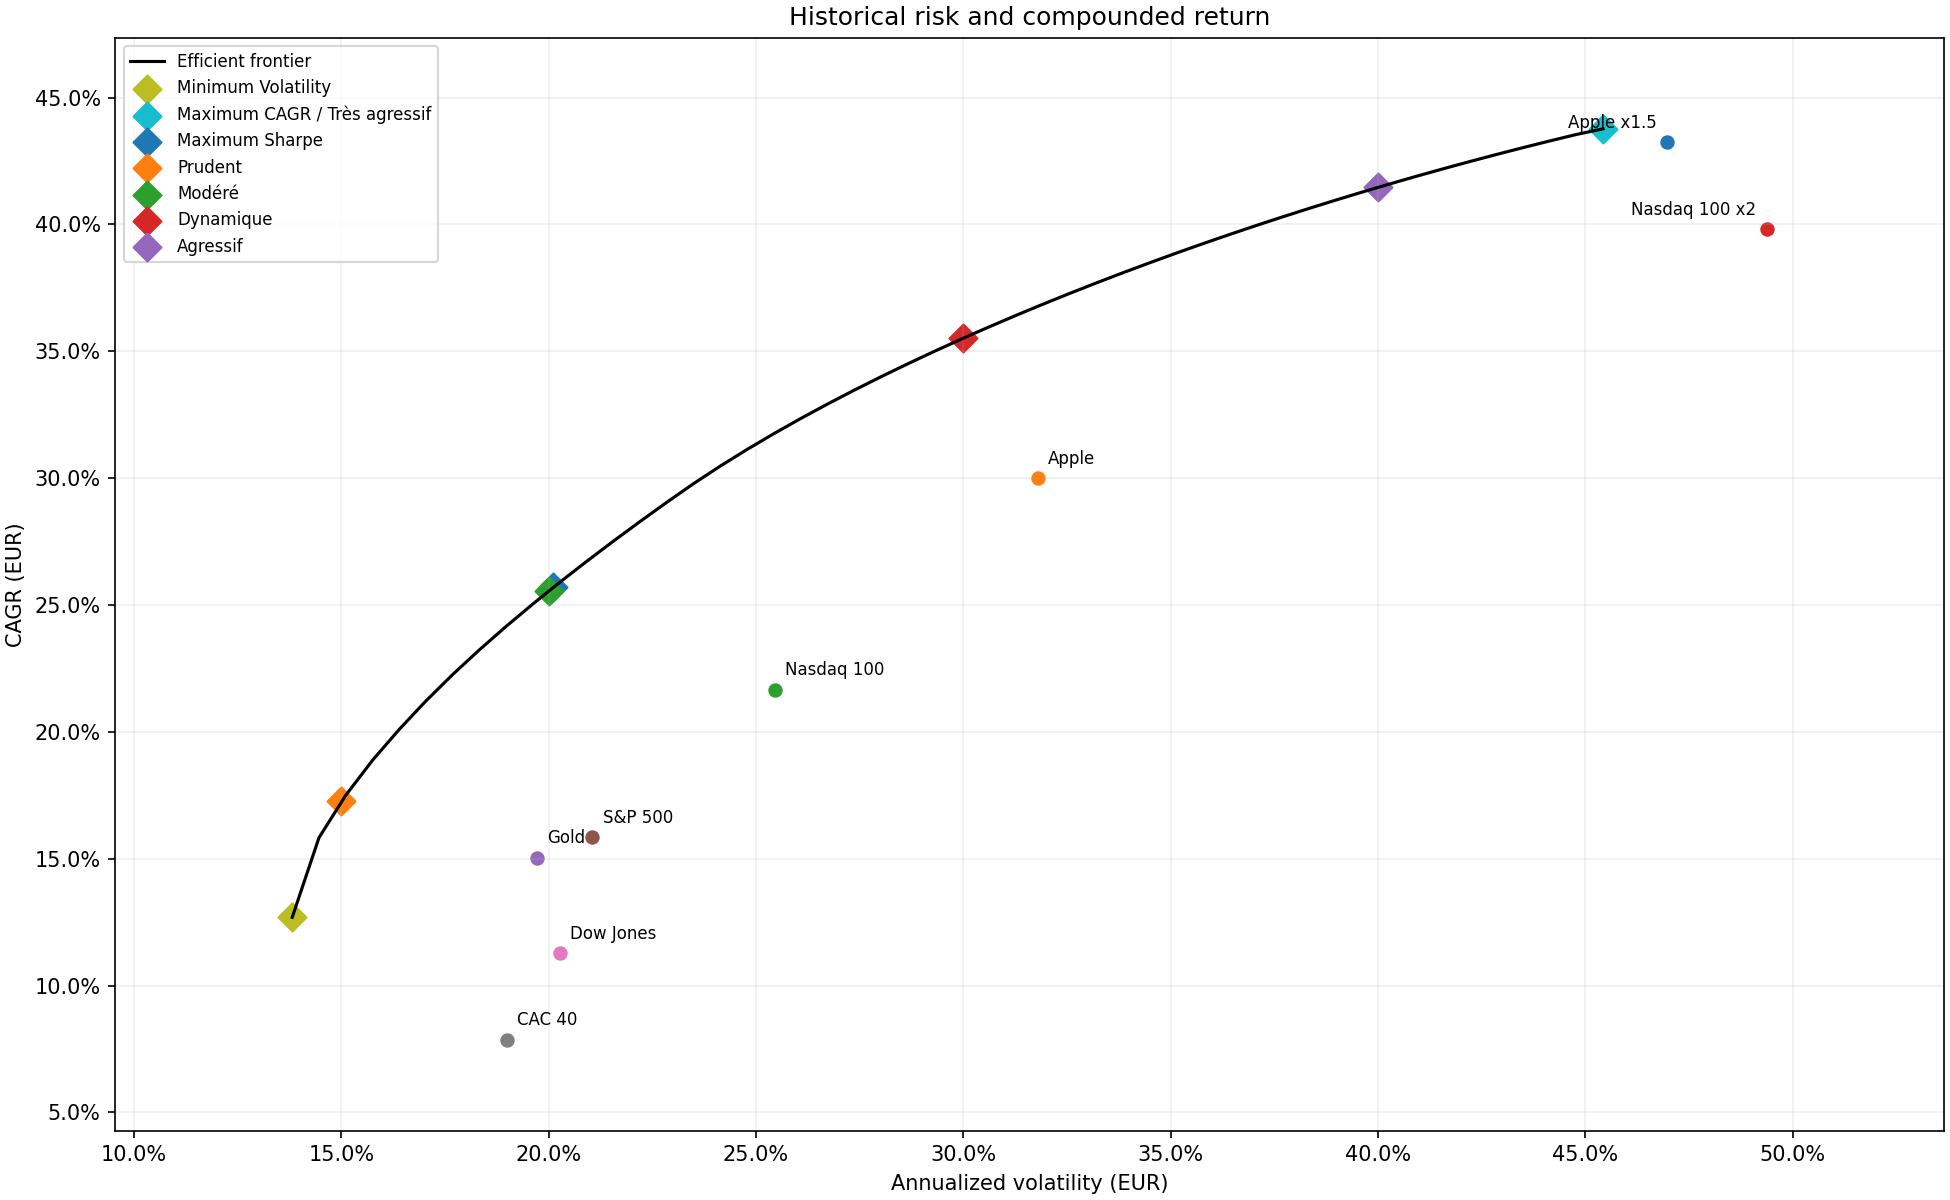

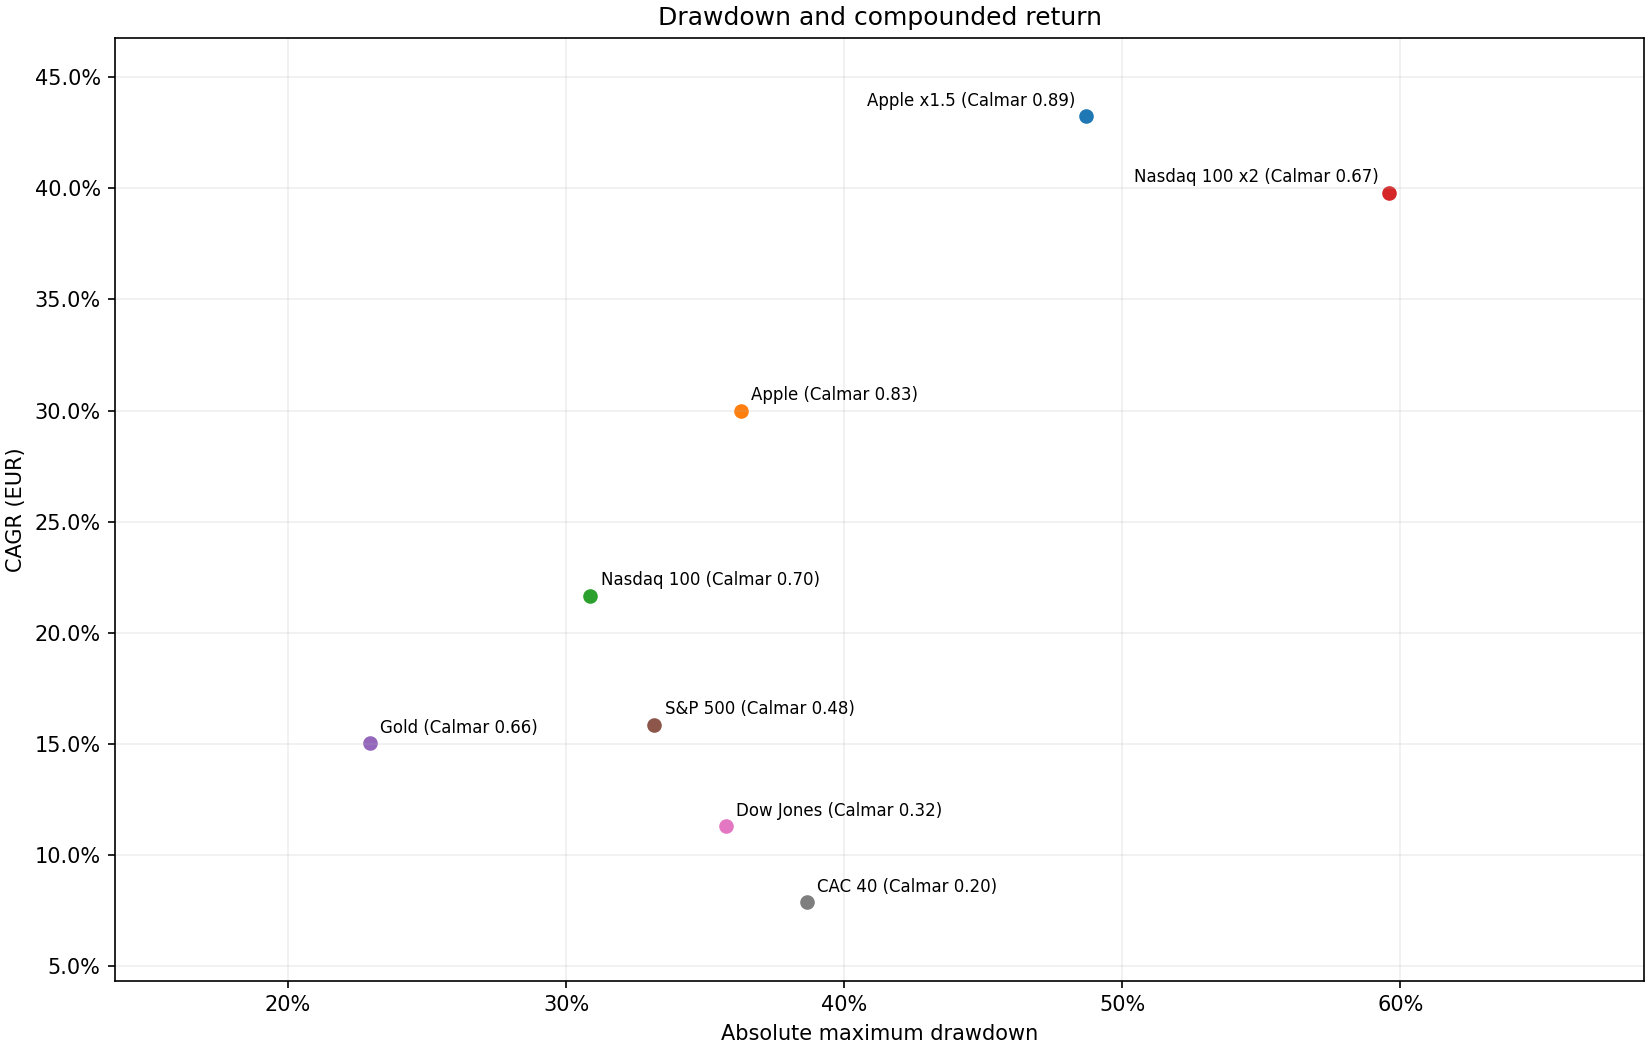

In [7]:
sanity = write_review_outputs(data, prices, stats, leverage_diagnostics, optimization, config)
frontier_figure.savefig(config.output_dir / "frontier.png", dpi=150)
drawdown_figure.savefig(config.output_dir / "drawdown.png", dpi=150)
display(sanity)
display(Image(filename=str(config.output_dir / "frontier.png")))
display(Image(filename=str(config.output_dir / "drawdown.png")))
